# Introduction

Ce notebook présente une simulation d’une urne de Pólya généralisée. Le modèle est simple : deux couleurs, noir et blanc, et un mécanisme de renforcement qui dépend de la couleur tirée.

## Modèle mathématique

L’état de l’urne à l’instant $n$ est donné par
$$S_n = (B_n, W_n),$$
avec $B_n$ le nombre de boules noires et $W_n$ le nombre de boules blanches.

La probabilité de tirer une boule noire est
$$\mathbb{P}(\text{noir à l’étape } n) = \frac{B_n}{B_n + W_n}.
$$
Après chaque tirage, la couleur observée est renforcée par un nombre de boules supplémentaire.

In [53]:
import sys
import os
import numpy as np

sys.path.append(
    os.path.abspath("..")
)

from src.urn import PolyaUrn

## Paramètres de simulation

Nous définissons l’urne initiale et les paramètres de renforcement :

- état initial : $B_0 = 10$, $W_0 = 5$,
- renforcement noir : $a = 2$,
- renforcement blanc : $b = 1$.

Le paramètre de renforcement mesure l’effet de chaque tirage sur les tirages futurs.

In [54]:
urn = PolyaUrn(
    balls={"black": 10, "white": 5},
    reinforcements={"black": 2, "white": 1},
)

## Procédure de simulation

La procédure de simulation est la suivante :
1. on tire une boule au hasard selon la composition actuelle,
2. on observe sa couleur,
3. on ajoute le nombre de boules correspondant à cette couleur.

La trajectoire stochastique est ainsi définie par la suite des états successifs de l’urne.

In [55]:
for _ in range(10):
    print(urn.draw())

black
white
black
white
black
black
black
black
black
black


## État final et dépendance au passé

L’état final de l’urne après les tirages montre l’effet cumulé des renforcements. Chaque tirage influence la composition future, ce qui introduit une dépendance forte au passé.

In [56]:
urn.balls

{'black': 26, 'white': 7}

## Premières trajectoires

Nous extrayons maintenant les trajectoires du nombre de boules noires et blanches dans l’historique. Ces trajectoires montrent l’évolution absolue des compteurs.

In [57]:
black_counts = [
    state["black"]
    for state in urn.history
]

white_counts = [
    state["white"]
    for state in urn.history
]

## Visualisation des trajectoires

Le graphique suivant illustre les trajectoires des deux couleurs. Il permet d’observer si l’une des deux couleurs domine par renforcement successif.

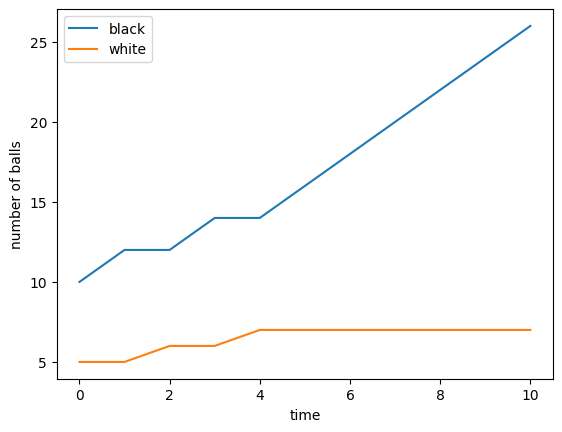

In [58]:
import matplotlib.pyplot as plt

plt.plot(black_counts, label="black")
plt.plot(white_counts, label="white")

plt.xlabel("time")
plt.ylabel("number of balls")

plt.legend()

plt.show()

## Évolution des proportions

Les proportions sont des quantités relatives qui rendent mieux compte de la composition de l’urne.
Nous calculons la proportion de boules noires :
$
\frac{B_n}{B_n + W_n}
$

Cette quantité est une trajectoire stochastique sur $[0,1]$.

In [59]:
proportions_black = [
    state["black"] /
    (state["black"] + state["white"])
    for state in urn.history
]

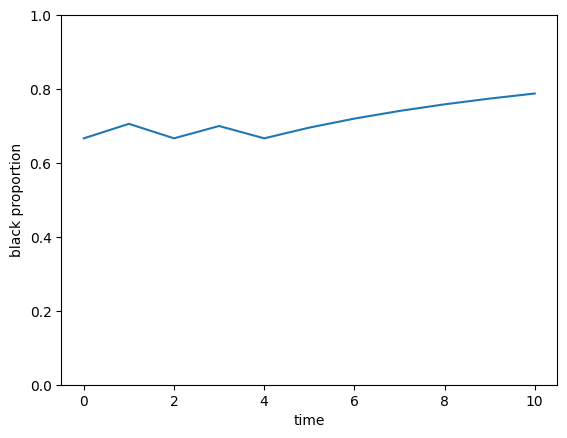

In [60]:
plt.plot(proportions_black)

plt.xlabel("time")
plt.ylabel("black proportion")

plt.ylim(0, 1)

plt.show()

## Interprétation probabiliste

La dynamique des proportions montre l’influence du renforcement :
- si les tirages noirs sont fréquents, la proportion noire augmente,
- si les tirages blancs dominent, la proportion noire diminue.

Le modèle illustre une dépendance au passé, car les probabilités de tirage évoluent avec la composition actuelle de l’urne.

# Comparaison entre renforcement symétrique et asymétrique

Nous comparons deux scénarios pour comprendre l'influence des paramètres de renforcement :

1. **Renforcement symétrique** : $a_\text{black} = a_\text{white} = 1$. Les deux couleurs sont renforcées de manière identique.
2. **Renforcement asymétrique** : $a_\text{black} = 2 > a_\text{white} = 1$. Les tirages noirs créent plus de renforcement.

Les conditions initiales sont identiques pour les deux urnes : $B_0 = 10$, $W_0 = 5$. Cela crée un avantage initial pour le noir, qui sera modulé différemment selon le mécanisme de renforcement.

In [61]:
urn_symmetric = PolyaUrn(
    balls={"black": 10, "white": 5},
    reinforcements={"black": 1, "white": 1},
)

for _ in range(100):
    urn_symmetric.draw()

**Cas symétrique** : chaque tirage renforce la couleur observée d'une unité. Malgré l'avantage initial du noir, le renforcement équilibré tend à stabiliser les proportions autour d'une valeur asymptotique qui reflète l'effet cumulé des tirages aléatoires.

**Cas asymétrique** : le renforcement du noir est plus fort. Les tirages noirs augmentent davantage la composition de l'urne. Cela amplifie l'effet de renforcement positif et peut conduire à une domination plus prononcée d'une couleur.

In [62]:
urn_asymmetric = PolyaUrn(
    balls={"black": 10, "white": 5},
    reinforcements={"black": 2, "white": 1},
)

for _ in range(100):
    urn_asymmetric.draw()

In [63]:
proportions_asymmetric = [
    state["black"] /
    (state["black"] + state["white"])
    for state in urn_asymmetric.history
]

In [64]:
proportions_symmetric = [
    state["black"] /
    (state["black"] + state["white"])
    for state in urn_symmetric.history
]

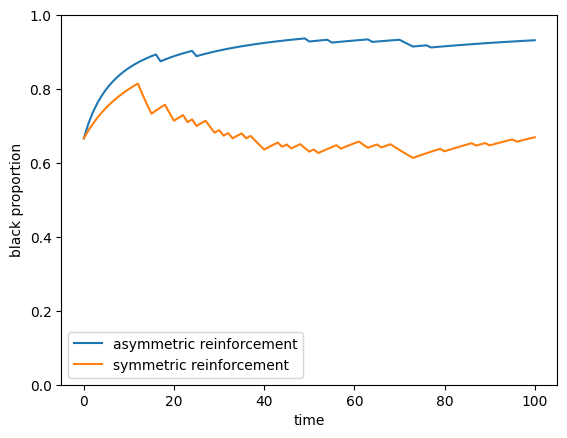

In [65]:
plt.plot(
    proportions_asymmetric,
    label="asymmetric reinforcement"
)

plt.plot(
    proportions_symmetric,
    label="symmetric reinforcement"
)

plt.xlabel("time")
plt.ylabel("black proportion")

plt.ylim(0, 1)

plt.legend()

plt.show()

## Observations et interprétation

**Asymétrie dans le renforcement** :
- La trajectoire asymétrique tend à converger plus rapidement vers des valeurs extrêmes (proches de 0 ou 1).
- La trajectoire symétrique montre des fluctuations plus régulières et une convergence moins prononcée vers les extrêmes.

**Rôle des conditions initiales** :
L'avantage initial $B_0 > W_0$ favorise les tirages noirs aux premiers instants. Cet effet aléatoire est amplifié par le renforcement asymétrique mais atténué par le renforcement symétrique.

**Fluctuations stochastiques** :
Les deux trajectoires montrent des variations dues au caractère aléatoire des tirages. Le cas asymétrique tend à amplifier ces fluctuations par feed-back positif, tandis que le cas symétrique les lisse davantage.

Cette comparaison illustre le rôle crucial des paramètres de renforcement : même avec des conditions initiales identiques, l'asymétrie du mécanisme de renforcement crée des dynamiques qualitativement différentes.

# Influence conjointe des conditions initiales et du renforcement

Jusqu'à présent, nous avons observé des cas où l'avantage initial favorisait aussi la couleur la plus fortement renforcée. Nous examinons maintenant une situation de **tension entre deux mécanismes** :

- **Avantage initial** : $B_0 = 20 \gg W_0 = 5$ (noir initialement dominant),
- **Renforcement inverse** : $a_\text{black} = 1 < a_\text{white} = 3$ (blanc fortement avantagé par le mécanisme).

L'enjeu est de comprendre comment la dynamique asymptotique du renforcement peut surmonter ou être subordonnée à l'avantage initial.

In [66]:
urn_inverse = PolyaUrn(
    balls={"black": 20, "white": 5},
    reinforcements={"black": 1, "white": 3},
)

for _ in range(100):
    urn_inverse.draw()

**Paramétrisation** : le blanc hérite d'un renforcement trois fois plus fort que le noir. Même minoritaire, chaque tirage blanc crée un effet de "rattrapage" beaucoup plus prononcé. Cette asymétrie forte crée une compétition dynamique où le passé récent joue un rôle critique.

## Visualisation et analyse

La trajectoire des proportions révèle l'interaction entre deux forces opposées : l'avantage initial du noir et la domination progressive du blanc par renforcement.

In [67]:
proportions_inverse = [
    state["black"] /
    (state["black"] + state["white"])
    for state in urn_inverse.history
]

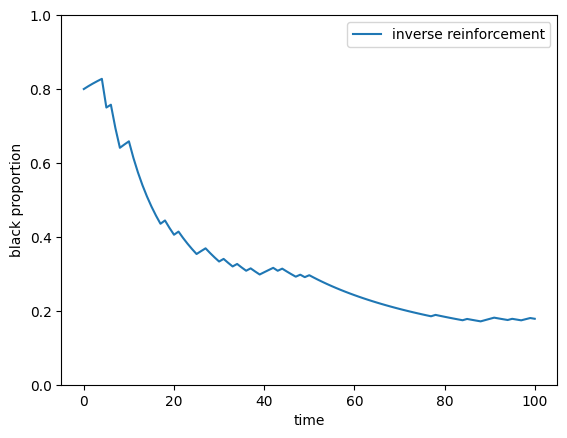

In [68]:
plt.plot(
    proportions_inverse,
    label="inverse reinforcement"
)

plt.xlabel("time")
plt.ylabel("black proportion")

plt.ylim(0, 1)

plt.legend()

plt.show()

## Interprétation

**Phase initiale** :
La proportion de noir commence proche de 0.8. L'avantage initial domine largement, et les premières trajectoires sont fortement "mémorisées" par les conditions initiales.

**Phase de transition** :
Graduellement, les tirages blancs, même moins fréquents, créent un renforcement plus agressif. Ce mécanisme asymétrique crée un effet de "rattrapage différé" : le blanc accumule une croissance plus forte par tirage, compensant progressivement son désavantage numérique.

**Interaction aléa-dynamique** :
Les fluctuations aléatoires **précoces** sont amplifiées ou atténuées selon le renforcement. Une série de tirages blancs au début peut créer une accélération de la croissance blanche. Inversement, une domination du noir au début retarde sa prise en charge.

**Dépendance au passé** :
L’urne est un processus markovien renforcé : la composition actuelle de l’urne résume l’ensemble de l’historique des tirages passés à travers le mécanisme de renforcement. Chaque tirage précédent a laissé une trace par le renforcement, qui continue d'influencer les probabilités futures.

**Conclusion** :
L'avantage initial peut être surpassé par une asymétrie de renforcement suffisante, mais seulement progressivement. L'horizon temporel de la simulation est crucial : avec suffisamment de tirages, la couleur la plus fortement renforcée tend à dominer, mais l'histoire du hasard ancien continue d'influencer les trajectoires observées.